In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from __future__ import annotations
from pathlib import Path


In [5]:
PROJECT_ROOT = Path.cwd()
PROJECT_ROOT = PROJECT_ROOT.parents[1]
CSV_PATH_DIR = PROJECT_ROOT / "data" 
CSV_FILE_PATH = CSV_PATH_DIR / "curated" / "real_cern_training_dataset" / "training_dataset.csv"

In [6]:
cern_df = pd.read_csv(CSV_FILE_PATH)
cern_df.head()

,gen_event_present,gen_event_weight_count,gen_event_weight_min,gen_event_weight_max,gen_event_weight_mean,gen_event_weight_std,gen_event_weight_sum,gen_event_weight_unique_count,gen_event_qscale,gen_particles_present,gen_particle_count,gen_particle_id_min,gen_particle_id_max,gen_particle_id_mean,gen_particle_id_std,gen_particle_id_sum,gen_particle_id_unique_count,ak5_genjets_present,label
0,True,2,1.0,1.0,1.0,0.0,2.0,1,30.10180,True,313,1.0,313.0,157.0,90.354856,49141.0,313,True,signal
1,True,2,1.0,1.0,1.0,0.0,2.0,1,21.19460,True,472,1.0,472.0,236.5,136.254358,111628.0,472,True,signal
2,True,2,1.0,1.0,1.0,0.0,2.0,1,56.14310,True,650,1.0,650.0,325.5,187.638615,211575.0,650,True,signal
3,True,2,1.0,1.0,1.0,0.0,2.0,1,22.96830,True,891,1.0,891.0,446.0,257.209383,397386.0,891,True,signal
4,True,2,1.0,1.0,1.0,0.0,2.0,1,6.70126,True,271,1.0,271.0,136.0,78.230429,36856.0,271,True,signal


In [7]:
cern_df.sum().isnull()

gen_event_present                False
gen_event_weight_count           False
gen_event_weight_min             False
gen_event_weight_max             False
gen_event_weight_mean            False
gen_event_weight_std             False
gen_event_weight_sum             False
gen_event_weight_unique_count    False
gen_event_qscale                 False
gen_particles_present            False
gen_particle_count               False
gen_particle_id_min              False
gen_particle_id_max              False
gen_particle_id_mean             False
gen_particle_id_std              False
gen_particle_id_sum              False
gen_particle_id_unique_count     False
ak5_genjets_present              False
label                            False
dtype: bool

In [8]:
cern_df.shape

(4000, 19)

In [12]:
cern_df["label"].value_counts()

label
signal        2000
background    2000
Name: count, dtype: int64

In [13]:
cern_df.isnull().sum()

gen_event_present                0
gen_event_weight_count           0
gen_event_weight_min             0
gen_event_weight_max             0
gen_event_weight_mean            0
gen_event_weight_std             0
gen_event_weight_sum             0
gen_event_weight_unique_count    0
gen_event_qscale                 0
gen_particles_present            0
gen_particle_count               0
gen_particle_id_min              0
gen_particle_id_max              0
gen_particle_id_mean             0
gen_particle_id_std              0
gen_particle_id_sum              0
gen_particle_id_unique_count     0
ak5_genjets_present              0
label                            0
dtype: int64

In [15]:
cern_df.nunique().sort_values()

gen_event_present                   1
gen_particle_id_min                 1
ak5_genjets_present                 1
gen_event_weight_unique_count       1
gen_event_weight_sum                1
gen_particles_present               1
gen_event_weight_mean               1
gen_event_weight_max                1
gen_event_weight_min                1
gen_event_weight_count              1
gen_event_weight_std                1
label                               2
gen_particle_count               1027
gen_particle_id_max              1027
gen_particle_id_mean             1027
gen_particle_id_std              1027
gen_particle_id_sum              1027
gen_particle_id_unique_count     1027
gen_event_qscale                 3999
dtype: int64

In [16]:
cern_df.groupby("label").mean(numeric_only=True).T

label,background,signal
gen_event_present,1.000000,1.000000
gen_event_weight_count,2.000000,2.000000
gen_event_weight_min,1.000000,1.000000
gen_event_weight_max,1.000000,1.000000
gen_event_weight_mean,1.000000,1.000000
gen_event_weight_std,0.000000,0.000000
gen_event_weight_sum,2.000000,2.000000
gen_event_weight_unique_count,1.000000,1.000000
gen_event_qscale,64.872674,36.865390
gen_particles_present,1.000000,1.000000


In [17]:
variable_features = [
    "gen_event_qscale",
    "gen_particle_count",
    "gen_particle_id_max",
    "gen_particle_id_mean",
    "gen_particle_id_std",
    "gen_particle_id_sum",
    "gen_particle_id_unique_count",
]
cern_df.groupby("label")[variable_features].agg(["mean", "median", "std", "min", "max"]).T

label                                  background        signal
gen_event_qscale             mean    6.487267e+01  3.686539e+01
                             median  6.157079e+01  2.402060e+01
                             std     2.249384e+01  3.918924e+01
                             min     2.113331e+01  2.507240e+00
                             max     1.838759e+02  4.150790e+02
gen_particle_count           mean    6.645265e+02  6.032825e+02
                             median  6.490000e+02  5.800000e+02
                             std     2.568820e+02  2.478870e+02
                             min     1.360000e+02  1.290000e+02
                             max     1.597000e+03  1.543000e+03
gen_particle_id_max          mean    6.645265e+02  6.032825e+02
                             median  6.490000e+02  5.800000e+02
                             std     2.568820e+02  2.478870e+02
                             min     1.360000e+02  1.290000e+02
                             max     1.597000e+03  1.543000e+03
gen_particle_id_mean         mean    3.327633e+02  3.021413e+02
                             median  3.250000e+02  2.905000e+02
                             std     1.284410e+02  1.239435e+02
                             min     6.850000e+01  6.500000e+01
                             max     7.990000e+02  7.720000e+02
gen_particle_id_std          mean    1.918320e+02  1.741524e+02
                             median  1.873499e+02  1.674313e+02
                             std     7.415554e+01  7.155895e+01
                             min     3.925876e+01  3.723797e+01
                             max     4.610141e+02  4.454256e+02
gen_particle_id_sum          mean    2.541077e+05  2.129852e+05
                             median  2.109250e+05  1.684900e+05
                             std     1.865555e+05  1.665695e+05
                             min     9.316000e+03  8.385000e+03
                             max     1.276003e+06  1.191196e+06
gen_particle_id_unique_count mean    6.645265e+02  6.032825e+02
                             median  6.490000e+02  5.800000e+02
                             std     2.568820e+02  2.478870e+02
                             min     1.360000e+02  1.290000e+02
                             max     1.597000e+03  1.543000e+03

In [19]:
eda_df = cern_df.copy()
eda_df["label_numeric"] = eda_df["label"].map({"background":0, "signal":1})

eda_df[variable_features + ["label_numeric"]].corr()["label_numeric"].sort_values(ascending=False)

label_numeric                   1.000000
gen_particle_id_sum            -0.115518
gen_particle_count             -0.120458
gen_particle_id_max            -0.120458
gen_particle_id_mean           -0.120458
gen_particle_id_unique_count   -0.120458
gen_particle_id_std            -0.120458
gen_event_qscale               -0.401503
Name: label_numeric, dtype: float64

In [20]:
cern_df[variable_features].corr(numeric_only=True)

,gen_event_qscale,gen_particle_count,gen_particle_id_max,gen_particle_id_mean,gen_particle_id_std,gen_particle_id_sum,gen_particle_id_unique_count
gen_event_qscale,1.000000,0.112003,0.112003,0.112003,0.112003,0.103415,0.112003
gen_particle_count,0.112003,1.000000,1.000000,1.000000,1.000000,0.976278,1.000000
gen_particle_id_max,0.112003,1.000000,1.000000,1.000000,1.000000,0.976278,1.000000
gen_particle_id_mean,0.112003,1.000000,1.000000,1.000000,1.000000,0.976278,1.000000
gen_particle_id_std,0.112003,1.000000,1.000000,1.000000,1.000000,0.976278,1.000000
gen_particle_id_sum,0.103415,0.976278,0.976278,0.976278,0.976278,1.000000,0.976278
gen_particle_id_unique_count,0.112003,1.000000,1.000000,1.000000,1.000000,0.976278,1.000000


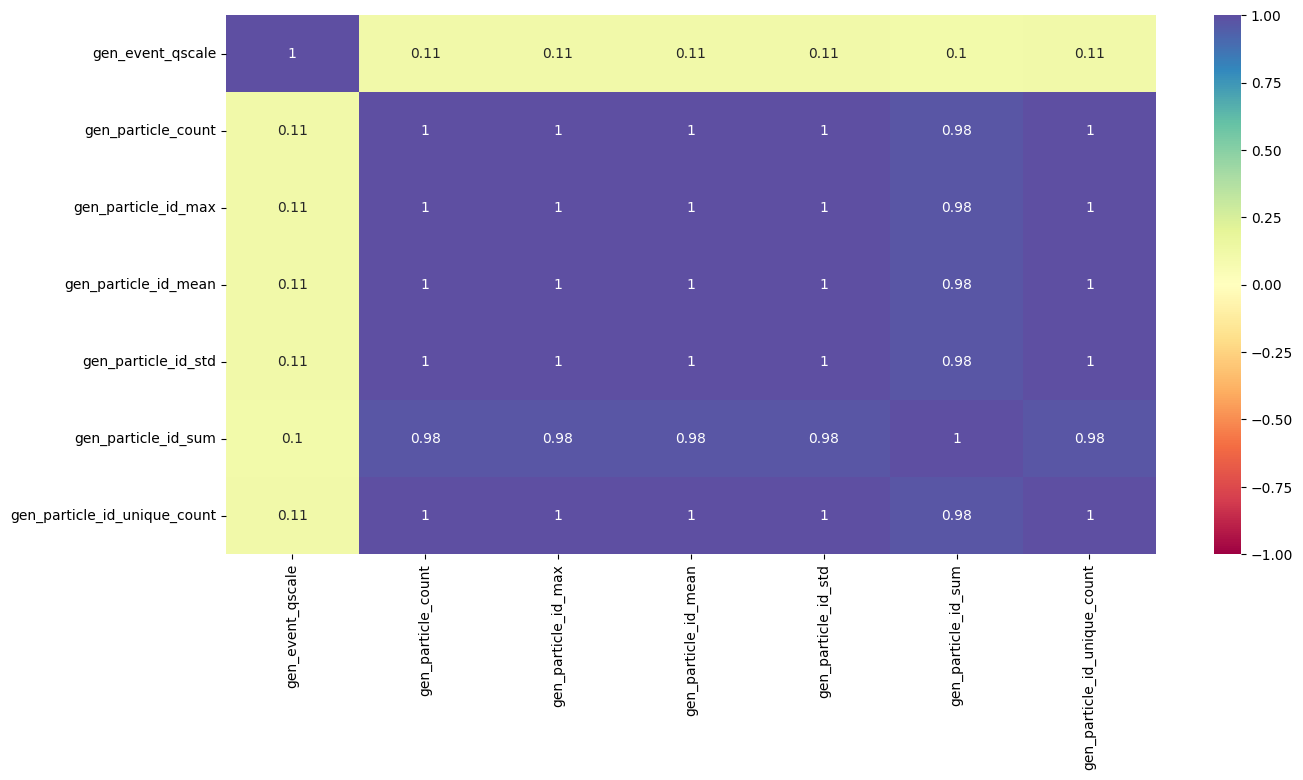

In [27]:
plt.figure(figsize=(15, 7))
sns.heatmap(
    cern_df[variable_features].corr(numeric_only=True), annot=True, vmin=-1, vmax=1, cmap="Spectral"
)
plt.show()